# VAE evaluation

In this notebook, we are going to evalute the training results of the vae (`train_vae.py`). Biggest take away is, are the following:
- Posterior collapse (1–2 of 16 dims active) → low diversity in generated samples
- No class conditioning → mode-averaging instead of class-specific generation
- Narrow generated variance → synthetic data doesn't cover the real data spread

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import umap

from data import CLASSES, BreathDataset, load_dataset, split_dataset
from models.vae import VAE, CVAE

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

## VAE

Before starting with the evaluation, we load the best models with there respective checkpoints into a dict and also define some useful variables.

In [2]:
regions = ['mouth', 'nose']
channel_names = ['Humidity in %', 'Temperature in °C']
class_colors = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
models = {} 
datasets = {}
splits = {}

for region in regions:
    # load dataset
    df = load_dataset()
    df = df[df["region"] == region].reset_index(drop=True)
    df_train, df_val, df_test = split_dataset(df, random_state=42)

    # datasets
    train_ds = BreathDataset(df_train)
    val_ds = BreathDataset(df_val,  stats=train_ds.stats)
    test_ds = BreathDataset(df_test, stats=train_ds.stats)
    datasets[region] = {"train": train_ds, "val": val_ds, "test": test_ds}
    splits[region] = {"train": df_train, "val": df_val, "test": df_test}

    # model
    ckpt_path = f"checkpoints/vae_{region}.pt"
    model = VAE(latent_dim=16).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    models[region] = model

We plot total loss, reconstruction loss, and KL divergence over 500 epochs for both mouth and nose VAEs to verify convergence and detect overfitting. The dashed line marks where the $\beta$-warmup reaches $\beta=1$, i.e., where the KL term enters at full weight. Both train and validation losses converge rapidly within ~50 epochs and remain closely aligned throughout, indicating no overfitting. The KL divergence shows a brief spike around the $\beta=1$ transition before settling, suggesting the latent space adjusts smoothly to the full regularization pressure.

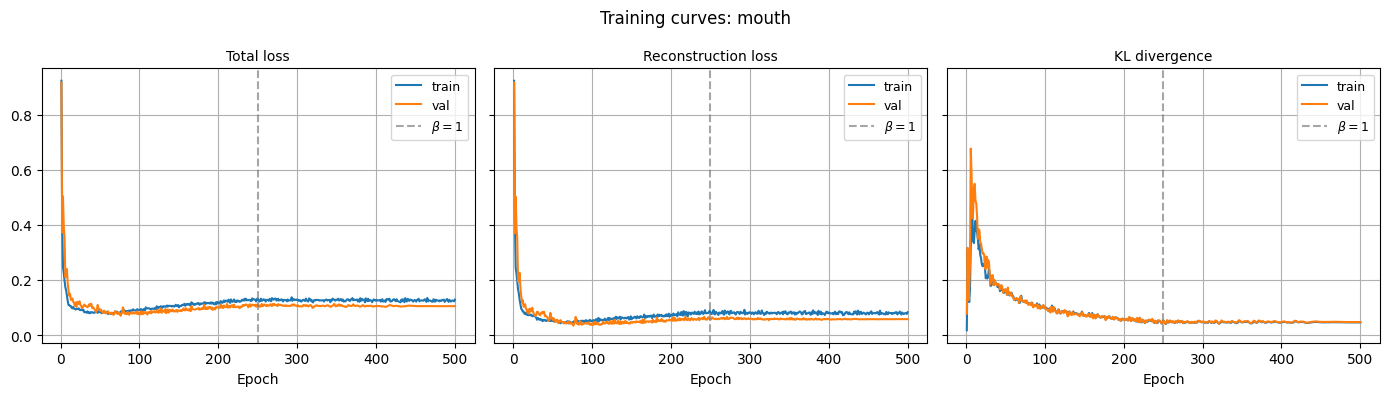

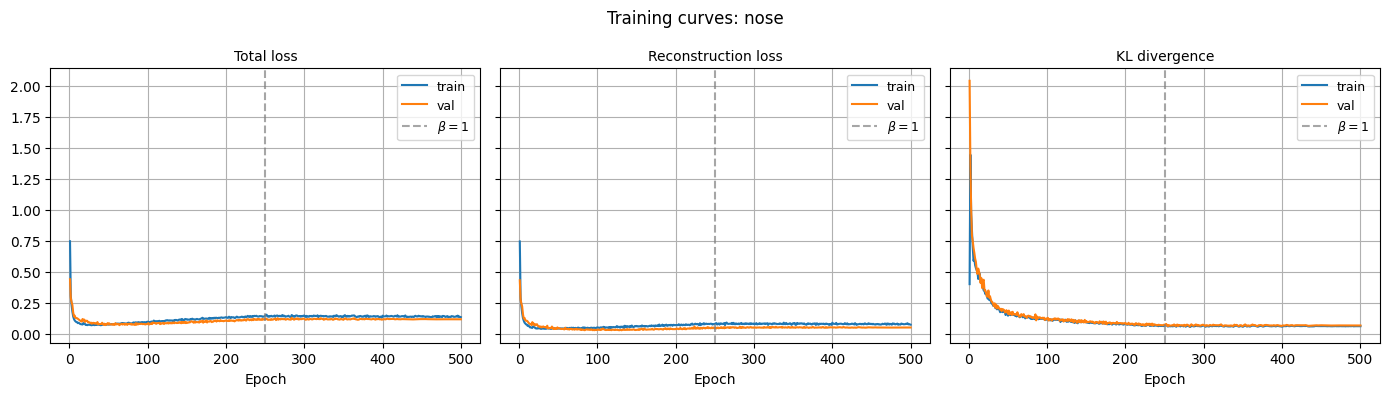

In [3]:
for region in regions:
    path = f'results/vae/train_{region}.csv'
    hist = pd.read_csv(path)
    beta1_epoch = hist.loc[hist['beta'] >= 1.0, 'epoch'].min()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle(f'Training curves: {region}')
    pairs = [('train_loss', 'val_loss', 'Total loss'),
            ('train_recon', 'val_recon','Reconstruction loss'),
            ('train_kl', 'val_kl', 'KL divergence')]
    for ax, (tr_col, vl_col, title) in zip(axes, pairs):
        ax.plot(hist['epoch'], hist[tr_col], label='train')
        ax.plot(hist['epoch'], hist[vl_col], label='val')
        ax.axvline(beta1_epoch, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid()
    plt.tight_layout()
    plt.show()

We overlay real and reconstructed signals for randomly selected validation samples to qualitatively assess whether the VAE captures the key temporal dynamics, onset timing, rise slope, and saturation level, across both channels (humidity, temperature) and both modalities (mouth, nose). The VAE faithfully reconstructs the dominant signal morphology for both modalities. The smoothing effect is acceptable for synthetic data generation, as the class-discriminative features (onset timing, rise dynamics) are preserved.

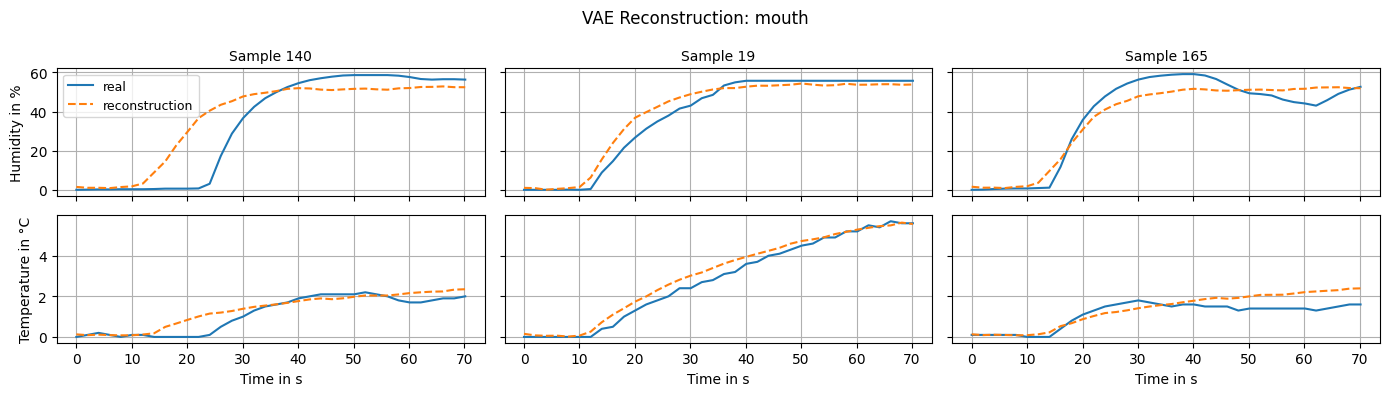

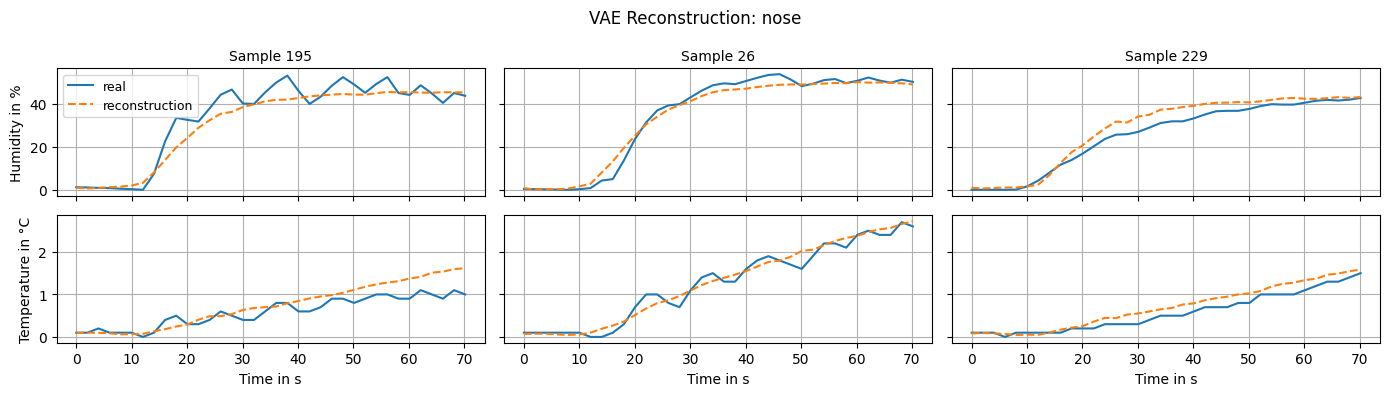

In [4]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
    fig.suptitle(f'VAE Reconstruction: {region}')

    # sample 3 signals from train_ds
    sample_indices = np.random.default_rng(42).choice(len(train_ds), size=3, replace=False)
    for col, idx in enumerate(sample_indices):
        signal, time, label = train_ds[idx]
        signal_batch = signal.unsqueeze(0).to(device)
        with torch.no_grad():
            x_hat, _, _ = model(signal_batch)
        x_hat      = denorm(x_hat.squeeze(0).cpu().numpy())
        signal_np  = denorm(signal.numpy())
        time_np    = time.numpy()

        for row in range(2):
            ax = axes[row, col]
            ax.plot(time_np, signal_np[row], label='real', color='tab:blue')
            ax.plot(time_np, x_hat[row], label='reconstruction', color='tab:orange', linestyle='--')
            ax.grid()
            axes[row, 0].set_ylabel(channel_names[row])
            axes[0, col].set_title(f'Sample {idx}')
            axes[0, 0].legend(loc='upper left')
            axes[-1, col].set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()

We compare per-class reconstruction error on the test set to check whether the VAE encodes all breathing patterns equally well or exhibits bias toward certain classes, which would affect synthetic data quality downstream. Eupnea achieves the lowest MSE (~0.038), followed by bradypnea (~0.050) and tachypnea (~0.060). This ordering is plausible, eupnea signals are the most regular and thus easiest to reconstruct, while tachypnea's faster dynamics and bradypnea's larger variance make them slightly harder to capture. Reconstruction quality is reasonably uniform across classes for both modalities, with no single class being drastically under-represented in the latent space. The wide error bars reflect sample-level variability rather than systematic bias.

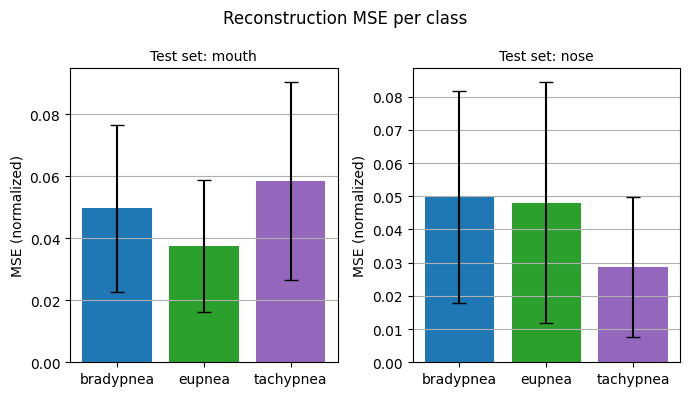

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4))
plt.suptitle('Reconstruction MSE per class')
for region_idx, region in enumerate(regions):
    test_ds = datasets[region]['test']
    model = models[region]
    model.eval()

    mse_per_class = {i: [] for i in range(len(CLASSES))}
    with torch.no_grad():
        for i in range(len(test_ds)):
            signal, _, label = test_ds[i]
            x_hat, _, _ = model(signal.unsqueeze(0).to(device))
            mse = (x_hat.squeeze(0) - signal.to(device)).pow(2).mean().item()
            mse_per_class[label].append(mse)
    means = [np.mean(mse_per_class[i]) for i in range(len(CLASSES))]
    stds  = [np.std(mse_per_class[i])  for i in range(len(CLASSES))]

    ax = fig.axes[region_idx]
    ax.bar(CLASSES, means, yerr=stds, capsize=5, color=list(class_colors.values()))
    ax.set_ylabel('MSE (normalized)')
    ax.set_title(f'Test set: {region}')
    ax.grid(axis='y')
plt.tight_layout()
plt.show()

We project the learned latent representations using PCA, t-SNE, and UMAP to visualize whether the VAE organizes breathing classes into separable regions, which is a prerequisite for generating class-coherent synthetic samples. The latent space captures meaningful variation but does not produce fully separable class clusters, which is expected for a standard (non-conditional) VAE trained without label supervision. All three projections consistently confirm partial overlap between classes, most visibly between bradypnea and eupnea. For conditional generation, this motivates either conditioning the decoder on class labels (CVAE) or sampling from class-specific latent subregions.

/Users/leon/.pyenv/versions/ma/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/leon/.pyenv/versions/ma/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


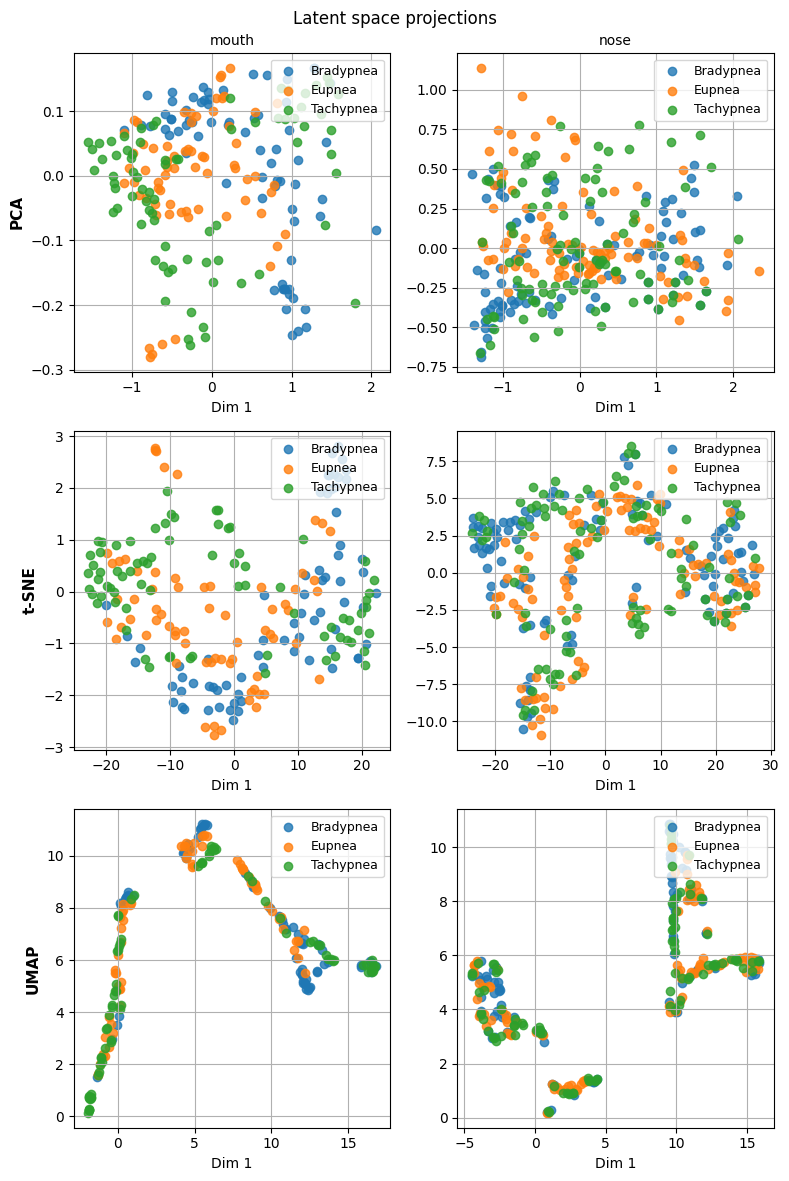

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(8, 12))
plt.suptitle('Latent space projections')

methods = [
    ('PCA',   lambda z: PCA(n_components=2).fit_transform(z)),
    ('t-SNE', lambda z: TSNE(n_components=2, random_state=42).fit_transform(z)),
    ('UMAP',  lambda z: umap.UMAP(n_components=2, random_state=42).fit_transform(z)),
]

for col, region in enumerate(regions):
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    mus, labels = [], []
    with torch.no_grad():
        for i in range(len(train_ds)):
            signal, _, label = train_ds[i]
            mu, _ = model.encoder(signal.unsqueeze(0).to(device))
            mus.append(mu.squeeze(0).cpu().numpy())
            labels.append(label)
    mus    = np.stack(mus)
    labels = np.array(labels)

    for row, (method_name, project) in enumerate(methods):
        z2d = project(mus)
        ax  = axes[row, col]
        for i, cls in enumerate(CLASSES):
            mask = labels == i
            ax.scatter(z2d[mask, 0], z2d[mask, 1], label=cls.capitalize(), alpha=0.8)
        if row == 0:
            ax.set_title(region)
        if col == 0:
            ax.set_ylabel(method_name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Dim 1')
        ax.legend(loc='upper right')
        ax.grid()

plt.tight_layout()
plt.show()

We sample from the learned prior $z \sim \mathcal{N}(0, I)$ and decode to inspect whether the VAE produces physically plausible breath signals, correct temporal structure (baseline → rise → saturation), realistic amplitude ranges, and coherent humidity-temperature coupling. The mouth VAE generates diverse, physically realistic samples. The nose VAE produces plausible but overly homogeneous outputs, a direct consequence of its more collapsed latent space. For downstream augmentation, nose samples may need additional strategies (e.g., latent space interpolation or noise injection) to improve diversity.

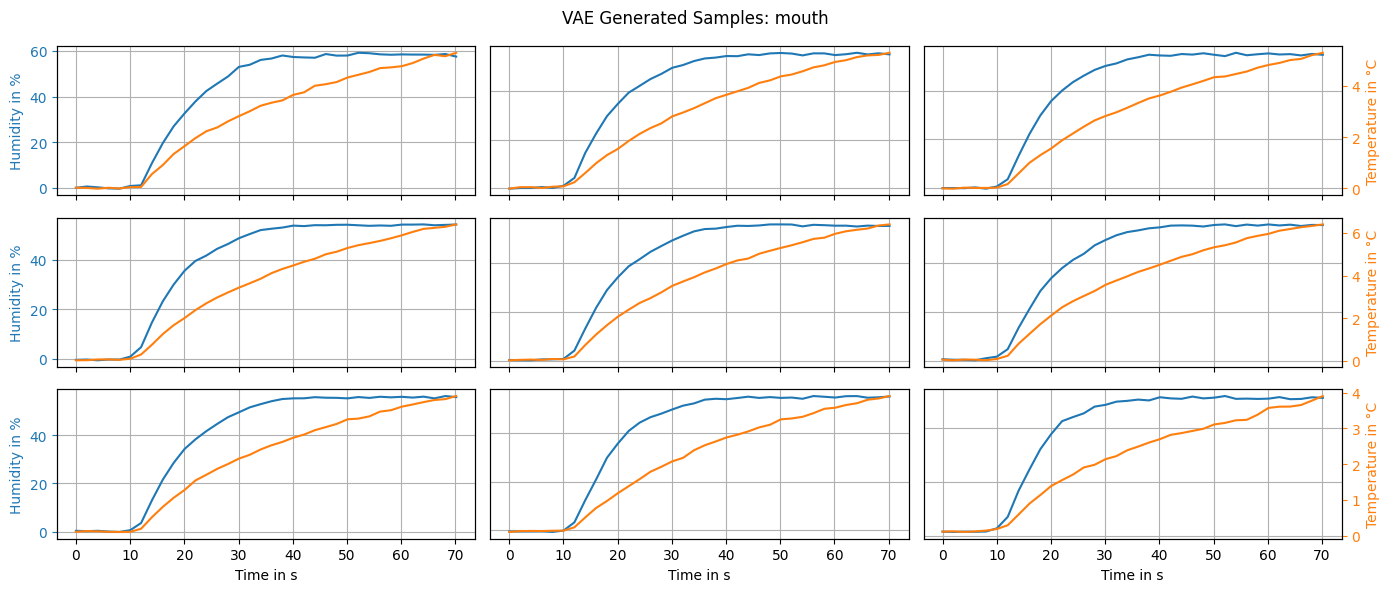

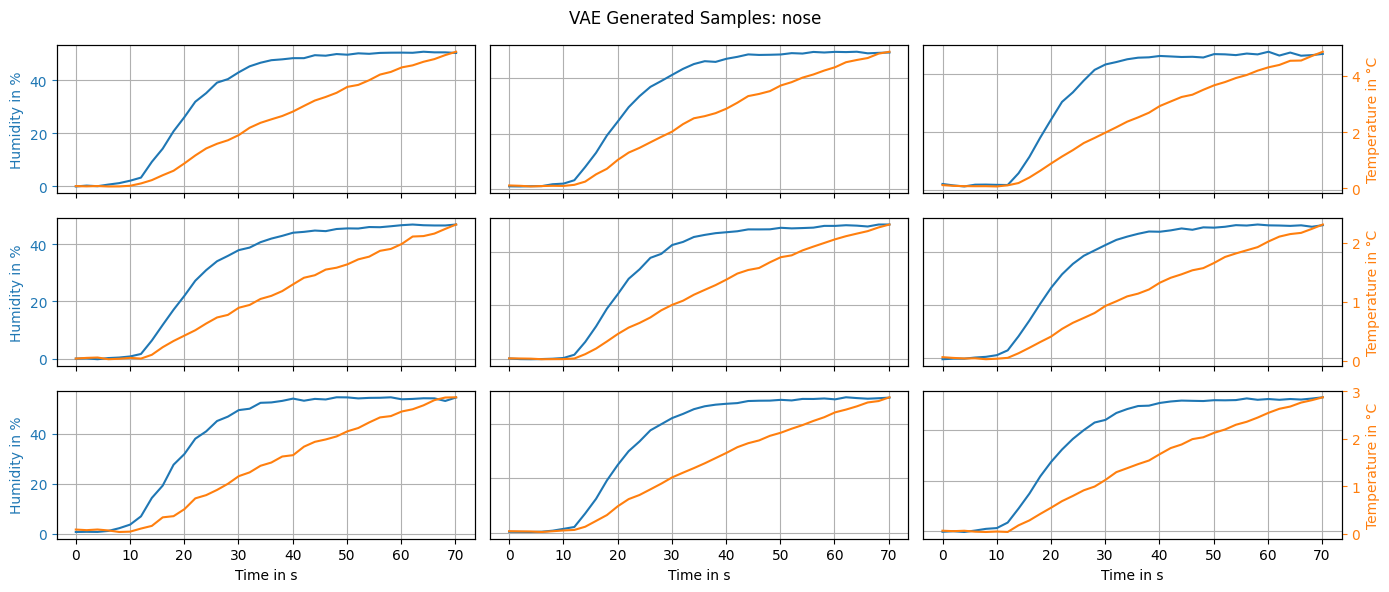

In [7]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()
    
    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean
    
    # plot
    samples  = denorm(model.sample(9, device).cpu().numpy())
    time_np  = train_ds[0][1].numpy()

    fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=False)
    fig.suptitle(f'VAE Generated Samples: {region}')
    for i, ax in enumerate(axes.flatten()):
        row = i // 3
        col = i % 3
        l1, = ax.plot(time_np, samples[i, 0], color='tab:blue', label='Humidity in %')
        ax.grid()
        ax_r = ax.twinx()
        l2, = ax_r.plot(time_np, samples[i, 1], color='tab:orange', label='Temperature in °C')
        if col == 0:
            ax.set_ylabel('Humidity in %', color='tab:blue')
            ax.tick_params(axis='y', colors='tab:blue')
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)
        if col == 2:
            ax_r.set_ylabel('Temperature in °C', color='tab:orange')
            ax_r.tick_params(axis='y', colors='tab:orange')
        else:
            ax_r.set_yticklabels([])
            ax_r.tick_params(axis='y', length=0)
        if row == 2:
            ax.set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()


We overlay the per-class real signal statistics ($\mu \pm \sigma$) with the unconditional generated distribution to assess whether synthetic samples fall within the real data envelope and which class they most closely resemble. The unconditional VAE generates signals that are statistically plausible (within the real data envelope) but mode-averaging, it converges toward the dataset mean rather than preserving class-specific characteristics. This confirms that for class-conditional synthetic data generation, explicit conditioning (e.g., CVAE or class-guided sampling) will be necessary.

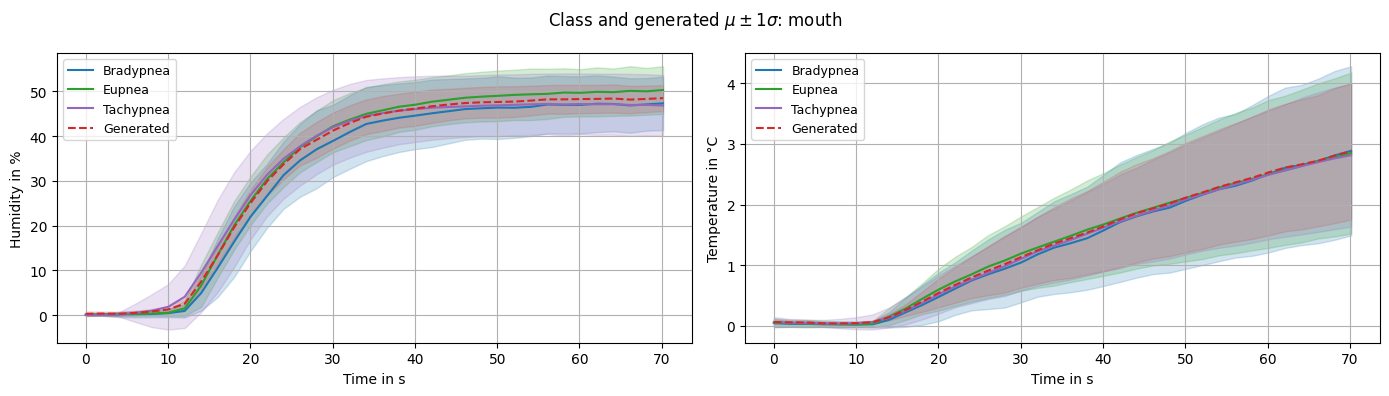

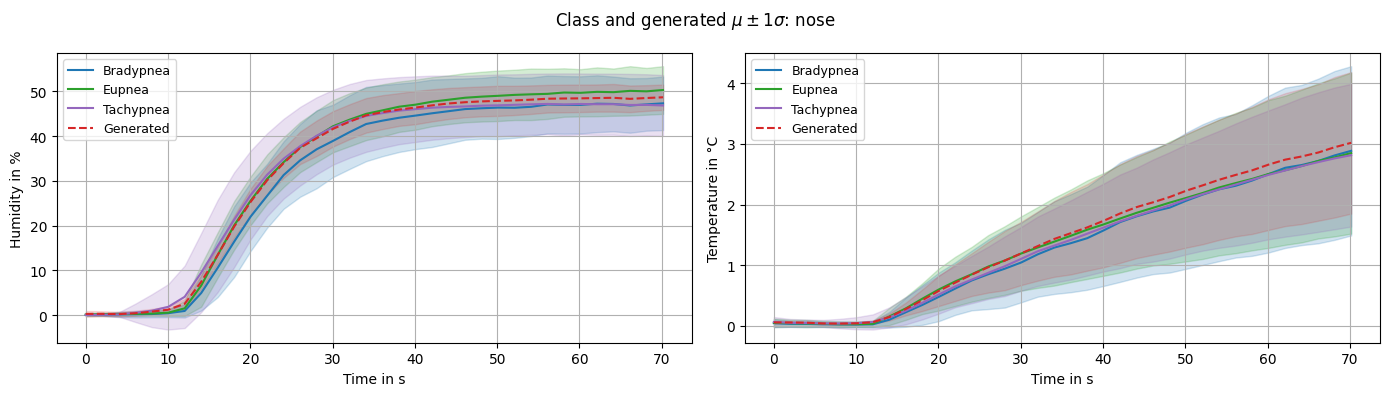

In [8]:
n_gen=200
for region in regions:
    mean_s = train_ds.stats['mean'][:, None]
    std_s  = train_ds.stats['std'][:, None]
    def denorm(x): return x * std_s + mean_s

    real = {i: [] for i in range(len(CLASSES))}
    for i in range(len(train_ds)):
        signal, _, label = train_ds[i]
        real[label].append(denorm(signal.numpy()))
    time_np = train_ds[0][1].numpy()
    gen     = denorm(model.sample(n_gen, device).cpu().numpy())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(rf'Class and generated $\mu \pm 1\sigma$: {region}')
    for ch, ax in enumerate(axes):
        for cls_idx, (cls_name, color) in enumerate(zip(CLASSES, class_colors.values())):
            sigs = np.stack(real[cls_idx])[:, ch, :]
            m, s = sigs.mean(0), sigs.std(0)
            ax.plot(time_np, m, color=color, label=cls_name.capitalize())
            ax.fill_between(time_np, m - s, m + s, alpha=0.2, color=color)
        m_gen, s_gen = gen[:, ch, :].mean(0), gen[:, ch, :].std(0)
        ax.plot(time_np, m_gen, color='tab:red', linestyle='--', label='Generated')
        ax.fill_between(time_np, m_gen - s_gen, m_gen + s_gen, alpha=0.15, color='tab:red')
        ax.set_ylabel(channel_names[ch])
        ax.set_xlabel('Time in s')
        ax.legend(loc='upper left')
        ax.grid()
    plt.tight_layout()
    plt.show()


## CVAE

Before starting with the evaluation, we load the best CVAE models with their respective checkpoints into a dict and also define some useful variables.

In [9]:
regions = ['mouth', 'nose']
channel_names = ['Humidity in %', 'Temperature in °C']
class_colors = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
models = {} 
datasets = {}
splits = {}

for region in regions:
    # load dataset
    df = load_dataset()
    df = df[df["region"] == region].reset_index(drop=True)
    df_train, df_val, df_test = split_dataset(df, random_state=42)

    # datasets
    train_ds = BreathDataset(df_train)
    val_ds = BreathDataset(df_val,  stats=train_ds.stats)
    test_ds = BreathDataset(df_test, stats=train_ds.stats)
    datasets[region] = {"train": train_ds, "val": val_ds, "test": test_ds}
    splits[region] = {"train": df_train, "val": df_val, "test": df_test}

    # model
    ckpt_path = f"checkpoints/cvae_{region}.pt"
    model = CVAE(latent_dim=16).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    models[region] = model

We plot total loss, reconstruction loss, and KL divergence over training epochs for both mouth and nose CVAEs to verify convergence and detect overfitting. The dashed line marks where the $\beta$-warmup reaches $\beta=1$, i.e., where the KL term enters at full weight.

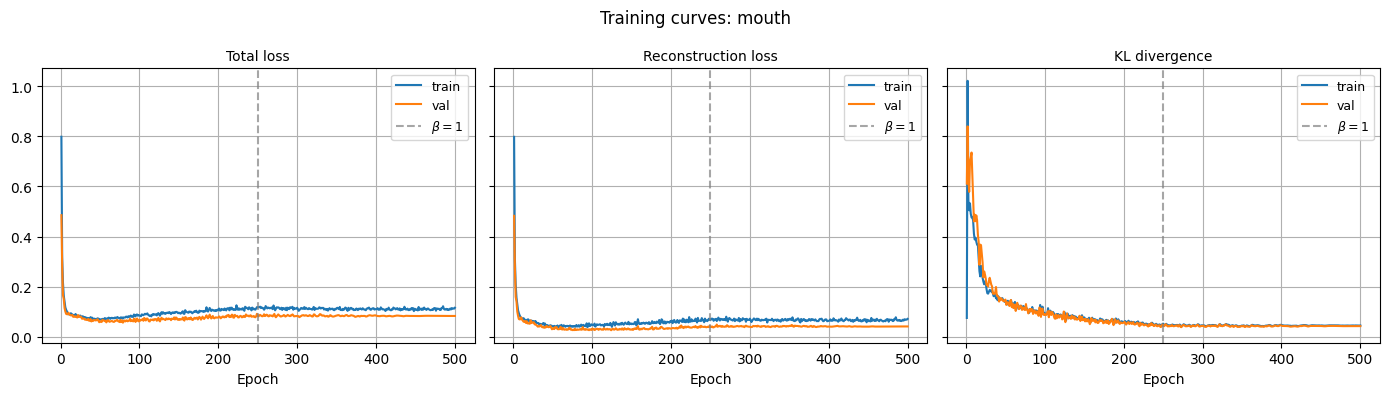

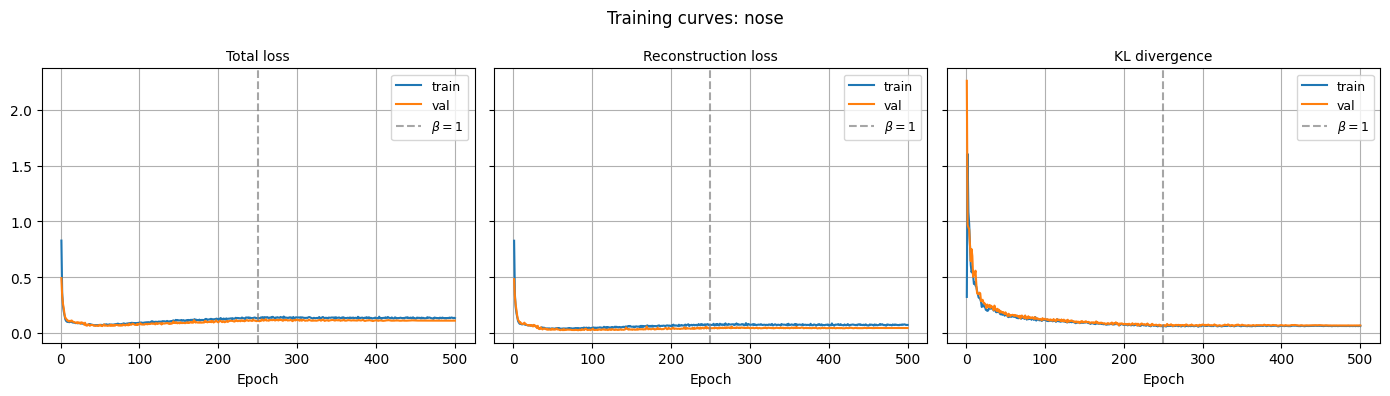

In [10]:
for region in regions:
    path = f'results/cvae/train_{region}.csv'
    hist = pd.read_csv(path)
    beta1_epoch = hist.loc[hist['beta'] >= 1.0, 'epoch'].min()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle(f'Training curves: {region}')
    pairs = [('train_loss', 'val_loss', 'Total loss'),
            ('train_recon', 'val_recon','Reconstruction loss'),
            ('train_kl', 'val_kl', 'KL divergence')]
    for ax, (tr_col, vl_col, title) in zip(axes, pairs):
        ax.plot(hist['epoch'], hist[tr_col], label='train')
        ax.plot(hist['epoch'], hist[vl_col], label='val')
        ax.axvline(beta1_epoch, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid()
    plt.tight_layout()
    plt.show()

We overlay real and reconstructed signals for randomly selected training samples to verify that the CVAE faithfully captures the signal morphology. Since the CVAE has access to the class label during the forward pass, subplot titles include the class to allow visual verification that the reconstructed shape matches the expected class-specific pattern (onset timing, rise slope, saturation).

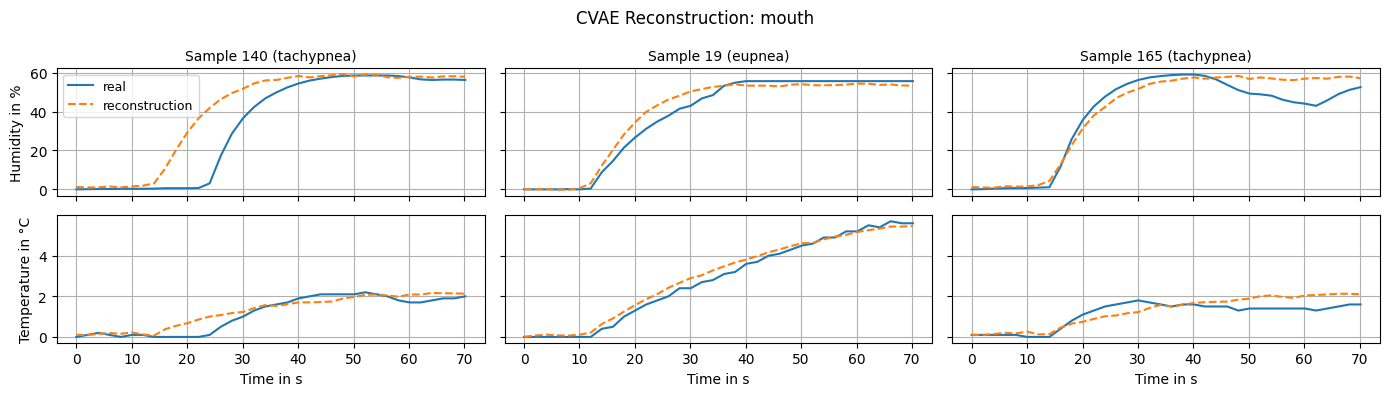

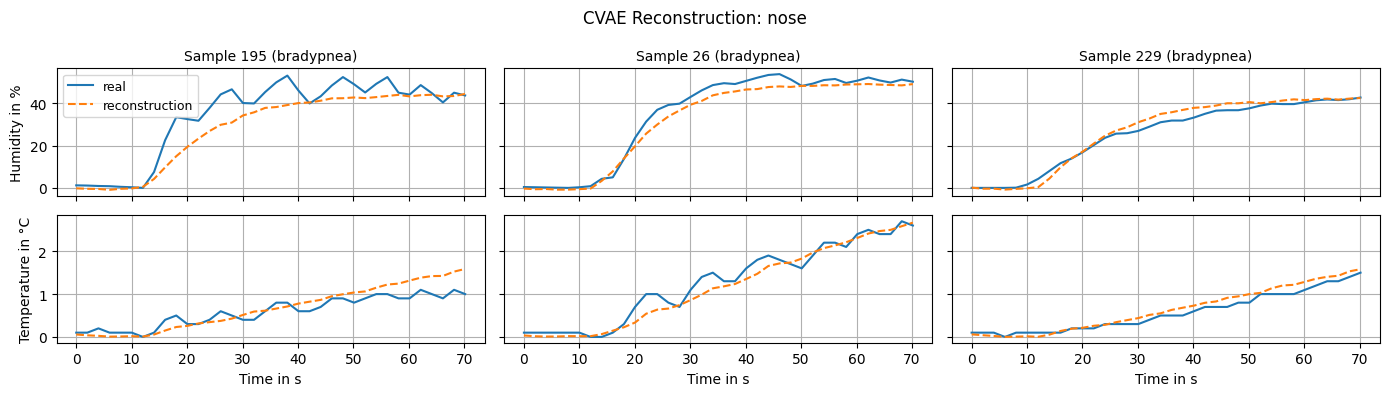

In [11]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
    fig.suptitle(f'CVAE Reconstruction: {region}')

    # sample 3 signals from train_ds
    sample_indices = np.random.default_rng(42).choice(len(train_ds), size=3, replace=False)
    for col, idx in enumerate(sample_indices):
        signal, time, label = train_ds[idx]
        signal_batch = signal.unsqueeze(0).to(device)
        label_t = torch.tensor([label]).long().to(device)
        with torch.no_grad():
            x_hat, _, _ = model(signal_batch, label_t)
        x_hat      = denorm(x_hat.squeeze(0).cpu().numpy())
        signal_np  = denorm(signal.numpy())
        time_np    = time.numpy()

        for row in range(2):
            ax = axes[row, col]
            ax.plot(time_np, signal_np[row], label='real', color='tab:blue')
            ax.plot(time_np, x_hat[row], label='reconstruction', color='tab:orange', linestyle='--')
            ax.grid()
            axes[row, 0].set_ylabel(channel_names[row])
            axes[0, col].set_title(f'Sample {idx} ({CLASSES[label]})')
            axes[0, 0].legend(loc='upper left')
            axes[-1, col].set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()

We compare per-class reconstruction error on the test set to check whether the CVAE encodes all breathing patterns equally well. Since the CVAE is conditioned on the class label during both encoding and decoding, we expect reconstruction quality to be more uniform across classes compared to the standard VAE, which must encode all classes into a shared unconditional latent space.

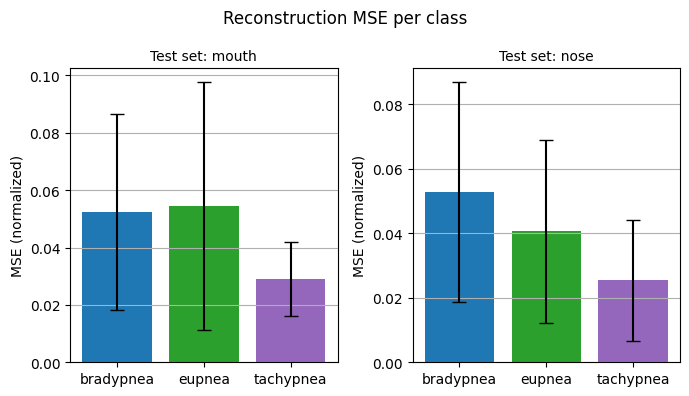

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4))
plt.suptitle('Reconstruction MSE per class')
for region_idx, region in enumerate(regions):
    test_ds = datasets[region]['test']
    model = models[region]
    model.eval()

    mse_per_class = {i: [] for i in range(len(CLASSES))}
    with torch.no_grad():
        for i in range(len(test_ds)):
            signal, _, label = test_ds[i]
            label_t = torch.tensor([label]).long().to(device)
            x_hat, _, _ = model(signal.unsqueeze(0).to(device), label_t)
            mse = (x_hat.squeeze(0) - signal.to(device)).pow(2).mean().item()
            mse_per_class[label].append(mse)
    means = [np.mean(mse_per_class[i]) for i in range(len(CLASSES))]
    stds  = [np.std(mse_per_class[i])  for i in range(len(CLASSES))]

    ax = fig.axes[region_idx]
    ax.bar(CLASSES, means, yerr=stds, capsize=5, color=list(class_colors.values()))
    ax.set_ylabel('MSE (normalized)')
    ax.set_title(f'Test set: {region}')
    ax.grid(axis='y')
plt.tight_layout()
plt.show()

We project the learned latent representations using PCA, t-SNE, and UMAP to visualize whether the CVAE organizes breathing classes into separable regions. Since the CVAE is class-conditioned at both encoding and decoding time, we expect clearer class separation compared to the standard VAE. Tighter, more distinct clusters would confirm that the conditioning signal is being used to structure the latent space meaningfully.

/Users/leon/.pyenv/versions/ma/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/leon/.pyenv/versions/ma/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


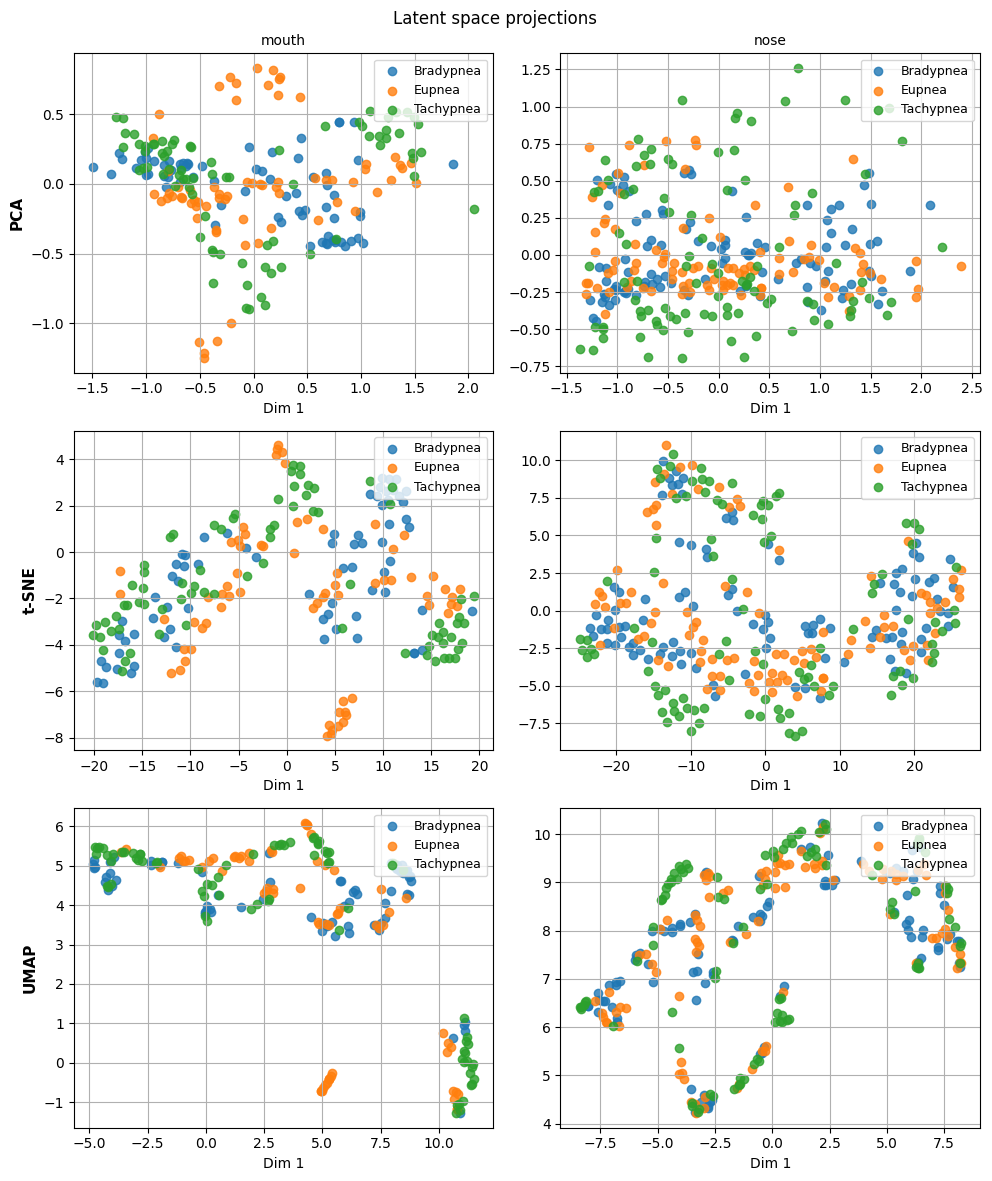

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
plt.suptitle('Latent space projections')

methods = [
    ('PCA',   lambda z: PCA(n_components=2).fit_transform(z)),
    ('t-SNE', lambda z: TSNE(n_components=2, random_state=42).fit_transform(z)),
    ('UMAP',  lambda z: umap.UMAP(n_components=2, random_state=42).fit_transform(z)),
]

for col, region in enumerate(regions):
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    mus, labels = [], []
    with torch.no_grad():
        for i in range(len(train_ds)):
            signal, _, label = train_ds[i]
            mu, _ = model.encoder(signal.unsqueeze(0).to(device),
                                  torch.tensor([label]).long().to(device))
            mus.append(mu.squeeze(0).cpu().numpy())
            labels.append(label)
    mus    = np.stack(mus)
    labels = np.array(labels)

    for row, (method_name, project) in enumerate(methods):
        z2d = project(mus)
        ax  = axes[row, col]
        for i, cls in enumerate(CLASSES):
            mask = labels == i
            ax.scatter(z2d[mask, 0], z2d[mask, 1], label=cls.capitalize(), alpha=0.8)
        if row == 0:
            ax.set_title(region)
        if col == 0:
            ax.set_ylabel(method_name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Dim 1')
        ax.legend(loc='upper right')
        ax.grid()

plt.tight_layout()
plt.show()


We sample from the prior $z \sim \mathcal{N}(0, I)$ conditioned on each class label to inspect whether the CVAE produces class-specific, physically plausible breath signals. Each column corresponds to one breathing class (bradypnea, eupnea, tachypnea), showing 3 independent samples. We expect class-specific morphological differences (onset timing, rise slope) to be clearly visible.

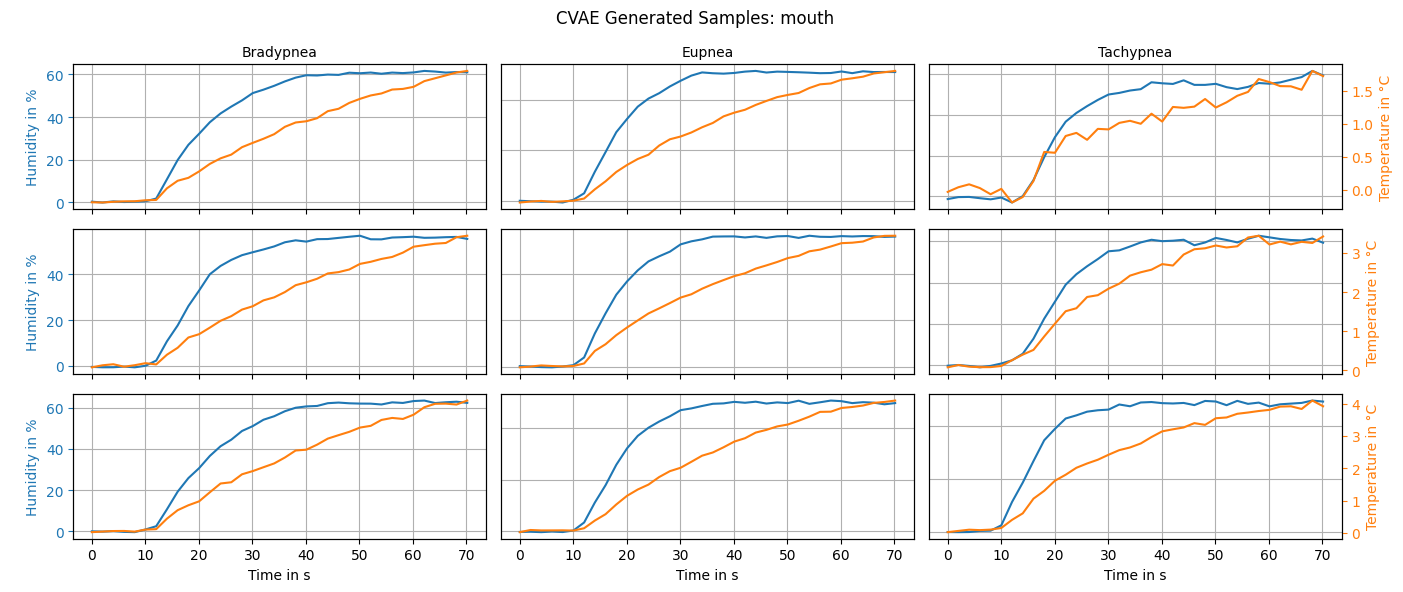

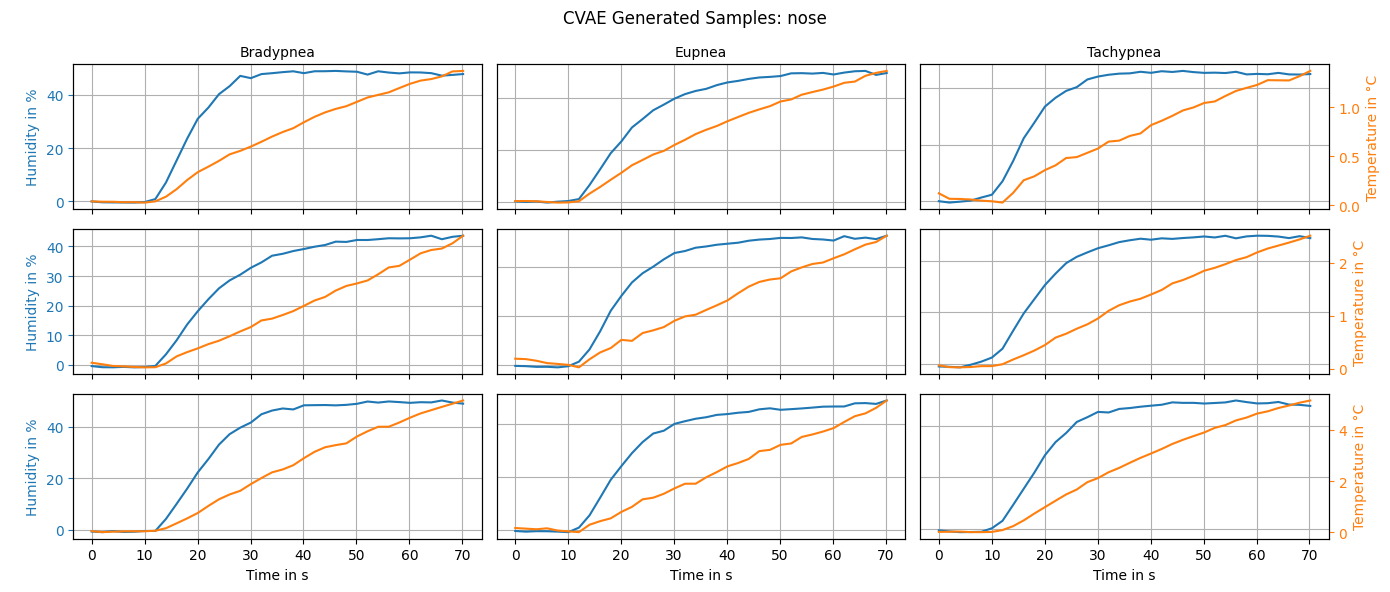

In [14]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    time_np = train_ds[0][1].numpy()

    fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=False)
    fig.suptitle(f'CVAE Generated Samples: {region}')

    for col, (cls, cls_idx) in enumerate(zip(CLASSES, range(len(CLASSES)))):
        samples = denorm(model.sample(3, torch.tensor(cls_idx).long(), device).cpu().numpy())
        for row in range(3):
            ax = axes[row, col]
            ax.plot(time_np, samples[row, 0], color='tab:blue')
            ax.grid()
            ax_r = ax.twinx()
            ax_r.plot(time_np, samples[row, 1], color='tab:orange')
            if row == 0:
                ax.set_title(f'{cls.capitalize()}')
            if col == 0:
                ax.set_ylabel(f'\n{channel_names[0]}', color='tab:blue')
                ax.tick_params(axis='y', colors='tab:blue')
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis='y', length=0)
            if col == 2:
                ax_r.set_ylabel(channel_names[1], color='tab:orange')
                ax_r.tick_params(axis='y', colors='tab:orange')
            else:
                ax_r.set_yticklabels([])
                ax_r.tick_params(axis='y', length=0)
            if row == 2:
                ax.set_xlabel('Time in s')

    plt.tight_layout()
    plt.show()


We overlay per-class real signal statistics ($\mu \pm \sigma$) with the class-conditional generated distribution to directly compare how well the CVAE matches each breathing class. Unlike the standard VAE (unconditional generation), the CVAE generates separately per class, so each class's synthetic mean and spread can be benchmarked against its real counterpart. Solid lines show real data, dashed lines show generated samples; matching solid/dashed pairs should overlap closely for a well-trained model.

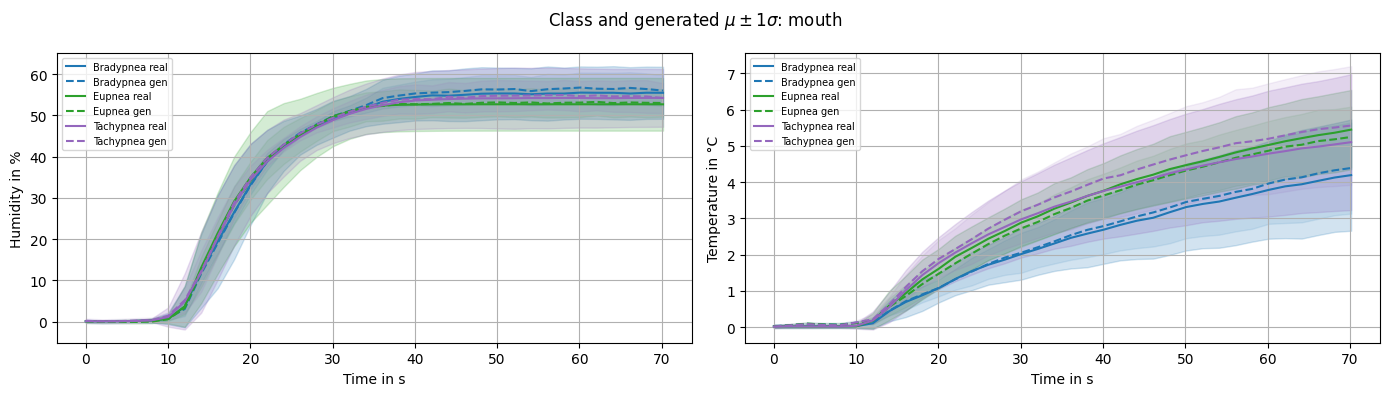

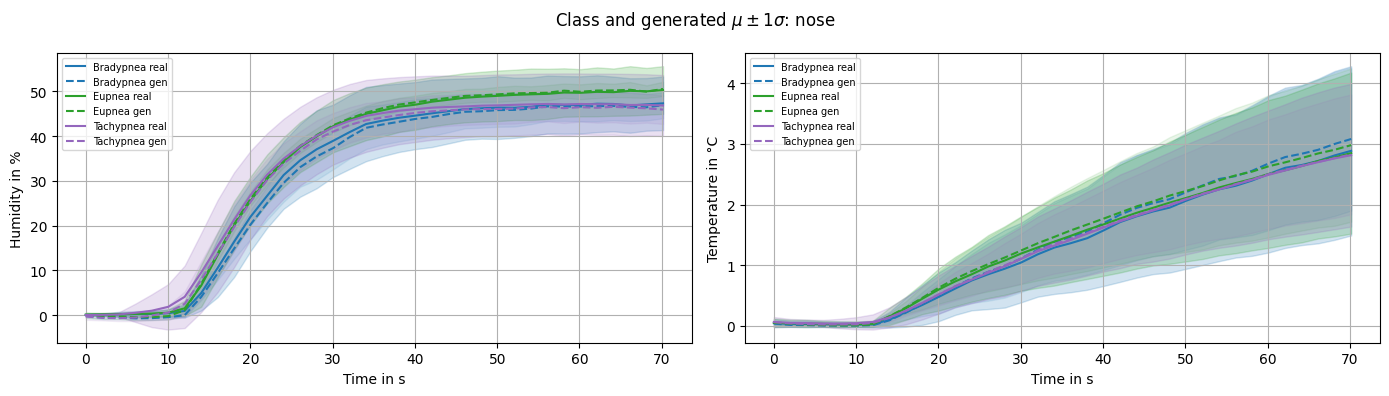

In [15]:
n_gen = 50
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    mean_s = train_ds.stats['mean'][:, None]
    std_s  = train_ds.stats['std'][:, None]
    def denorm(x): return x * std_s + mean_s

    real = {i: [] for i in range(len(CLASSES))}
    for i in range(len(train_ds)):
        signal, _, label = train_ds[i]
        real[label].append(denorm(signal.numpy()))
    time_np = train_ds[0][1].numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(rf'Class and generated $\mu \pm 1\sigma$: {region}')
    for ch, ax in enumerate(axes):
        for cls_idx, (cls_name, color) in enumerate(zip(CLASSES, class_colors.values())):
            sigs = np.stack(real[cls_idx])[:, ch, :]
            m, s = sigs.mean(0), sigs.std(0)
            ax.plot(time_np, m, color=color, label=f'{cls_name.capitalize()} real')
            ax.fill_between(time_np, m - s, m + s, alpha=0.2, color=color)
            gen = denorm(model.sample(n_gen, torch.tensor(cls_idx).long(), device).cpu().numpy())
            m_gen, s_gen = gen[:, ch, :].mean(0), gen[:, ch, :].std(0)
            ax.plot(time_np, m_gen, color=color, linestyle='--', label=f'{cls_name.capitalize()} gen')
            ax.fill_between(time_np, m_gen - s_gen, m_gen + s_gen, alpha=0.1, color=color)
        ax.set_ylabel(channel_names[ch])
        ax.set_xlabel('Time in s')
        ax.legend(loc='upper left', fontsize=7)
        ax.grid()
    plt.tight_layout()
    plt.show()